After tuning the ANN and Random Forest using the 2023 validation set,
the selected configurations are trained again using all matches from
2015 to 2023.

The final models are then evaluated on the test set containing matches
from 2024 and 2025.

The test set was not used during feature selection, model selection or
parameter tuning.

In [2]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import tensorflow as tf 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    log_loss, 
    confusion_matrix, 
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation 
from tensorflow.keras import Input 
from tensorflow.keras import optimizers

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (PROCESSED_DATA_DIR / "feature_split_matches.csv")

matches = pd.read_csv(input_file, parse_dates=["Date"])

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 49)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [6]:
final_train_data = matches.loc[
    matches["DataSplit"].isin(
        ["Training", "Validation"]
    )
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

In [8]:
print(
    "Final training matches:", 
    len(final_train_data)
)

print("Test matches:", len(test_data))

print(
    "Final training period: ",
    final_train_data["Date"].min(), 
    "-", 
    final_train_data["Date"].max()
)

print(
    "Test period: ", 
    test_data["Date"].min(), 
    "-", 
    test_data["Date"].max()
)

Final training matches: 21417
Test matches: 5119
Final training period:  2015-01-05 00:00:00 - 2023-12-31 00:00:00
Test period:  2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [9]:
assert (
    final_train_data["Date"].max() < test_data["Date"].min()
)

print("Final chronological split is correct.")

Final chronological split is correct.


In [10]:
numeric_features = [
    "Player1Rank",
    "Player2Rank",
    "Player1Points",
    "Player2Points",

    "Player1MatchesBefore",
    "Player2MatchesBefore",
    "ExperienceDifference",

    "Player1WinRateBefore",
    "Player2WinRateBefore",
    "WinRateDifference",

    "Player1Recent5WinRate",
    "Player2Recent5WinRate",
    "Recent5WinRateDifference",

    "Player1SurfaceMatchesBefore",
    "Player2SurfaceMatchesBefore",

    "Player1SurfaceWinRateBefore",
    "Player2SurfaceWinRateBefore",
    "SurfaceWinRateDifference",

    "H2HMatchesBefore",
    "Player1H2HWinRateBefore",
    "Player2H2HWinRateBefore",
    "DifferenceH2HWinRateBefore",

    "Player1DaysSinceLastMatch",
    "Player2DaysSinceLastMatch",

    "RankDifference",
    "PointsDifference"
]

In [11]:
X_final_train = final_train_data[numeric_features].copy()
y_final_train = final_train_data["Player1Won"].to_numpy()

X_test = test_data[numeric_features].copy()
y_test= test_data["Player1Won"].to_numpy()

In [12]:
print("Final training X:", X_final_train.shape)
print("Final training y:", y_final_train.shape)
print("Test X:", X_test.shape)
print("Test y:", y_test.shape)


Final training X: (21417, 26)
Final training y: (21417,)
Test X: (5119, 26)
Test y: (5119,)


In [13]:
final_training_medians = (X_final_train.median())
X_final_train = (
    X_final_train.fillna(
        final_training_medians
    )
)

X_test = X_test.fillna(final_training_medians)

In [15]:
print(
    "Missing final training values:", 
    X_final_train.isna().sum().sum()
)

print(
    "Missing test values:", 
    X_test.isna().sum().sum()
)

Missing final training values: 0
Missing test values: 0


Part A — Final ANN

Your selected ANN was:

16 hidden neurons
ReLU
learning rate 0.001
50 epochs

We now create a new model from scratch using those selected parameters.

We should not simply continue training the old ANN because that old network was trained only on 2015–2022.

In [16]:
normalizer = StandardScaler()
ANN_train_X = normalizer.fit_transform(X_final_train)
ANN_test_X = normalizer.transform(X_test)

In [17]:
num_instances, num_features = (ANN_train_X.shape)
print("Training matches:", num_instances)
print("Number of fetures:", num_features)

Training matches: 21417
Number of fetures: 26


In [18]:
#initialize final network
final_ann = Sequential()

#input
final_ann.add(Input(shape=(num_features,)))

#hidden layer
final_ann.add(Dense(16))
final_ann.add(Activation("relu"))

#output
final_ann.add(Dense(1))
final_ann.add(Activation("sigmoid"))

In [19]:
final_ann.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
final_ann_history = final_ann.fit(
    x= ANN_train_X,
    y= y_final_train, 
    epochs=50, 
    verbose=1
)

Epoch 1/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6382 - loss: 0.6299
Epoch 2/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step - accuracy: 0.6587 - loss: 0.6126
Epoch 3/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6622 - loss: 0.6103
Epoch 4/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6633 - loss: 0.6090
Epoch 5/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6640 - loss: 0.6081
Epoch 6/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - accuracy: 0.6628 - loss: 0.6075
Epoch 7/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.6643 - loss: 0.6070
Epoch 8/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step - accuracy: 0.6653 - loss: 0.6065
Epoch 9/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.6658 - loss: 0.6061
Epoch 10/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.6673 - loss: 0.6058
Epoch 11/50
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.6674 - loss: 0.6055
Epoch 12/50
670/670 ━━━━━━━━━━━━━━━━━━

In [21]:
# use the test data 
ann_test_probabilities = (
    final_ann.predict(
        ANN_test_X, 
        verbose=0
    ).reshape(-1)
)

ann_test_predictions = (
    ann_test_probabilities >= 0.5
).astype(int)

In [22]:
ann_test_results = {
    "Model": "ANN", 
    "Accuracy": accuracy_score(
        y_test, ann_test_predictions
    ), 
    "BalancedAccuracy": balanced_accuracy_score(
        y_test, ann_test_predictions
    ), 
    "Precision": precision_score(
        y_test, ann_test_predictions, zero_division=0
    ), 
    "Recall": recall_score(
        y_test, ann_test_predictions, zero_division=0
    ),
    "F1": f1_score(
        y_test, ann_test_predictions, zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test, ann_test_probabilities
    ), 
    "LogLoss": log_loss(
        y_test, ann_test_probabilities
    )
}

In [23]:
pd.DataFrame([ann_test_results])

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,ANN,0.648173,0.648185,0.653396,0.647082,0.650223,0.70454,0.623685


## final random forest
selected configuration: 
200 trees
maximum depth = 10
minimum samples per leaf = 1
max_features = sqrt

In [24]:
final_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    min_samples_leaf=1, 
    max_features="sqrt", 
    random_state=42, 
    n_jobs=-1
)

In [25]:
final_rf.fit(X_final_train, y_final_train)

rf_test_predictions = (final_rf.predict(X_test))
rf_test_probabilities = (final_rf.predict_proba(X_test)[:, 1])


In [26]:
rf_test_results = {
    "Model": "Random Forest", 
    "Accuracy": accuracy_score(
        y_test, rf_test_predictions
    ),
    "BalancedAccuracy": balanced_accuracy_score(
        y_test, rf_test_predictions
    ),
    "Precision": precision_score(
        y_test, rf_test_predictions, zero_division=0
    ),
    "Recall": recall_score(
        y_test, rf_test_predictions, zero_division=0
    ), 
    "F1": f1_score(
        y_test, rf_test_predictions, zero_division=0
    ), 
    "ROC_AUC": roc_auc_score(
        y_test, rf_test_probabilities
    ), 
    "LogLoss": log_loss(
        y_test, rf_test_probabilities
    )
}

pd.DataFrame([rf_test_results])

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,Random Forest,0.639383,0.639606,0.650549,0.618864,0.634311,0.706592,0.621153


In [27]:
## final comparison 

final_model_results = pd.DataFrame(
    [
        ann_test_results, 
        rf_test_results
    ]
)

final_model_results = (
    final_model_results.sort_values(
        by="Accuracy", ascending= False
    ).reset_index(drop=True)
)

final_model_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,ANN,0.648173,0.648185,0.653396,0.647082,0.650223,0.704540,0.623685
1,Random Forest,0.639383,0.639606,0.650549,0.618864,0.634311,0.706592,0.621153


In [28]:
ranking_test_predictions = np.where(
    test_data["RankDifference"] > 0, 
    1, 
    0
)

equal_rank = (
    test_data["RankDifference"] == 0
)

ranking_test_predictions[equal_rank] = np.where(
    test_data.loc[
        equal_rank, "PointsDifference"
    ] >= 0, 
    1, 
    0
)

In [29]:
ranking_test_results = {
    "Model": "Better-ranked player", 
    "Accuracy": accuracy_score(
        y_test, ranking_test_predictions
    ), 
    "BalancedAccuracy": balanced_accuracy_score(
        y_test, ranking_test_predictions
    ),
    "Precision": precision_score(
        y_test, ranking_test_predictions, zero_division=0
    ),
    "Recall": recall_score(
        y_test, ranking_test_predictions, zero_division=0
    ), 
    "F1": f1_score(
        y_test, ranking_test_predictions, zero_division=0
    )
}

In [30]:
test_comparison = pd.DataFrame(
    [
        {
            key: ann_test_results[key]
            for key in [
                "Model",
                "Accuracy",
                "BalancedAccuracy",
                "Precision",
                "Recall",
                "F1"
            ]
        }, 
        {
            key: rf_test_results[key]
            for key in [
                "Model",
                "Accuracy",
                "BalancedAccuracy",
                "Precision",
                "Recall",
                "F1"
            ]
        }, 
        ranking_test_results
    ]
)

test_comparison = (
    test_comparison.sort_values(
        by="Accuracy", ascending=False
    ).reset_index(drop=True)
)

test_comparison

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,ANN,0.648173,0.648185,0.653396,0.647082,0.650223
1,Better-ranked player,0.642508,0.642467,0.646308,0.646308,0.646308
2,Random Forest,0.639383,0.639606,0.650549,0.618864,0.634311


In [31]:
print("ANN")
print(
    classification_report(
        y_test, 
        ann_test_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

ANN
               precision    recall  f1-score   support

Player 2 wins       0.64      0.65      0.65      2532
Player 1 wins       0.65      0.65      0.65      2587

     accuracy                           0.65      5119
    macro avg       0.65      0.65      0.65      5119
 weighted avg       0.65      0.65      0.65      5119



In [32]:
print("Random Forest")
print(
    classification_report(
        y_test, 
        rf_test_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

Random Forest
               precision    recall  f1-score   support

Player 2 wins       0.63      0.66      0.64      2532
Player 1 wins       0.65      0.62      0.63      2587

     accuracy                           0.64      5119
    macro avg       0.64      0.64      0.64      5119
 weighted avg       0.64      0.64      0.64      5119



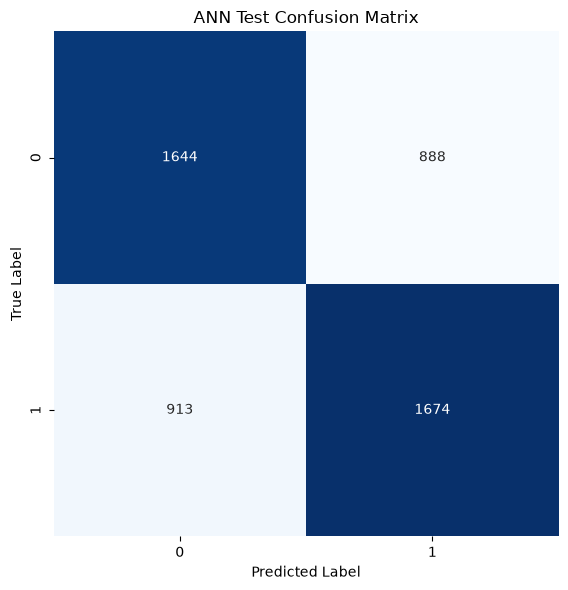

In [34]:
ann_matrix = confusion_matrix(y_test, ann_test_predictions)

fig, axes = plt.subplots(
    figsize =(6, 6),
    tight_layout=True
)

sns.heatmap(
    ann_matrix, 
    square=True, 
    annot=True, 
    fmt="d",
    cbar=False, 
    cmap="Blues"
)

axes.set_xlabel("Predicted Label")
axes.set_ylabel("True Label")
axes.set_title("ANN Test Confusion Matrix")
plt.show()

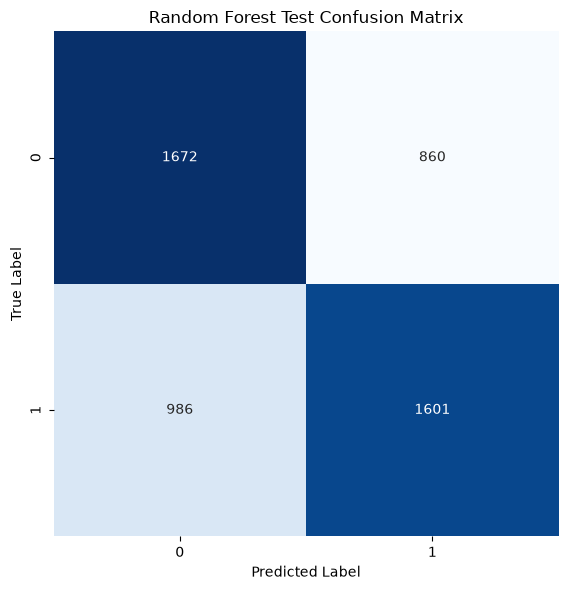

In [35]:
rf_matrix = confusion_matrix(y_test, rf_test_predictions)

fig, axes = plt.subplots(
    figsize=(6, 6), 
    tight_layout=True
)

sns.heatmap(
    rf_matrix, 
    square=True, 
    annot=True, 
    fmt="d",
    cbar=False, 
    cmap="Blues"
)

axes.set_xlabel("Predicted Label")
axes.set_ylabel("True Label")
axes.set_title("Random Forest Test Confusion Matrix")
plt.show()

In [36]:
final_feature_importance = pd.DataFrame(
    {
        "Feature": numeric_features, 
        "Importance": final_rf.feature_importances_
    }
)

final_feature_importance = (
    final_feature_importance.sort_values(
        by="Importance", ascending=False
    ).reset_index(drop=True)
)

final_feature_importance

,Feature,Importance
0,PointsDifference,0.135681
1,RankDifference,0.118532
2,WinRateDifference,0.077586
3,SurfaceWinRateDifference,0.070884
4,Player2Points,0.055523
5,Player1Points,0.051362
6,Player1Rank,0.047185
7,Player2Rank,0.046919
8,ExperienceDifference,0.044414
9,Player2WinRateBefore,0.036896


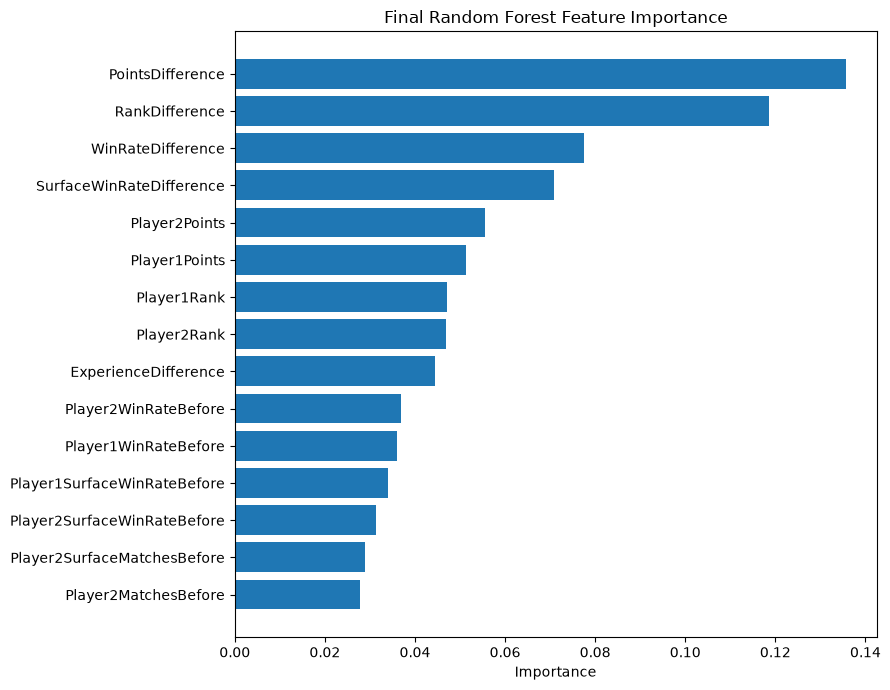

In [38]:
top_features = (
    final_feature_importance.head(15).sort_values(
        by="Importance", ascending=True
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"], 
    top_features["Importance"]
)

plt.title("Final Random Forest Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [40]:
test_analysis = test_data[
    [
        "MatchID",
        "Date",
        "Tournament",
        "Surface",
        "Round",
        "Player1",
        "Player2",

        "Player1Rank",
        "Player2Rank",
        "RankDifference",

        "PointsDifference",

        "WinRateDifference",
        "Recent5WinRateDifference",
        "SurfaceWinRateDifference",

        "H2HMatchesBefore",

        "Player1Won"
    ]
].copy()

In [ ]:
##add ANN results 
test_analysis["ANNProbability"] = ann_test_probabilities
test_analysis["ANNPrediction"] = ann_test_predictions
test_analysis["ANNCorrect"] = (
    test_analysis["ANNPrediction"] == test_analysis["Player1Won"]
)
test_analysis["ANNConfidence"] = np.maximum(
    test_analysis["ANNProbability"], 
    1- test_analysis["ANNProbability"]
)

In [42]:
#add RF results
test_analysis["RFProbability"] = rf_test_probabilities
test_analysis["RFPrediction"] = rf_test_predictions
test_analysis["RFCorrect"] = (
    test_analysis["RFPrediction"] == test_analysis["Player1Won"]
)
test_analysis["RFConfidence"] = np.maximum(
    test_analysis["RFProbability"], 
    1 - test_analysis["RFProbability"]
)


In [43]:
ann_most_wrong = (
    test_analysis.loc[
        test_analysis["ANNCorrect"] == False
    ].sort_values(
        by="ANNConfidence", ascending=False
    )
)

ann_most_wrong[
    [
        "Date",
        "Tournament",
        "Surface",
        "Player1",
        "Player2",
        "Player1Rank",
        "Player2Rank",
        "Player1Won",
        "ANNPrediction",
        "ANNProbability",
        "ANNConfidence"
    ]
].head(10)

,Date,Tournament,Surface,Player1,Player2,Player1Rank,Player2Rank,Player1Won,ANNPrediction,ANNProbability,ANNConfidence
22076,2024-03-12,BNP Paribas Open,Hard,Djokovic N.,Nardi L.,1.0,123.0,0,1,0.962394,0.962394
24587,2025-03-08,BNP Paribas Open,Hard,Brooksby J.,Auger-Aliassime F.,937.0,18.0,1,0,0.044768,0.955232
24747,2025-04-01,U.S.Men's Clay Court Championships,Clay,Hanfmann Y.,Mannarino A.,123.0,144.0,0,1,0.948526,0.948526
23530,2024-08-30,US Open,Hard,Alcaraz C.,Van De Zandschulp B.,3.0,74.0,0,1,0.909693,0.909693
25359,2025-06-19,Halle Open,Grass,Bublik A.,Sinner J.,45.0,1.0,1,0,0.094117,0.905883
21602,2024-01-18,Australian Open,Hard,Rune H.,Cazaux A.,8.0,122.0,0,1,0.900817,0.900817
21877,2024-02-21,Rio Open,Clay,Fonseca J.,Fils A.,655.0,36.0,1,0,0.102513,0.897487
22642,2024-05-24,Geneva Open,Clay,Machac T.,Djokovic N.,44.0,1.0,1,0,0.105733,0.894267
24557,2025-03-06,BNP Paribas Open,Hard,Brooksby J.,Bonzi B.,937.0,62.0,1,0,0.106377,0.893623
21822,2024-02-17,Argentina Open,Clay,Jarry N.,Alcaraz C.,21.0,2.0,1,0,0.106736,0.893264


In [44]:
ann_most_correct = (
    test_analysis.loc[
        test_analysis["ANNCorrect"] == True
    ].sort_values(
        by="ANNConfidence", ascending=False
    )
)

ann_most_correct[
    [
        "Date",
        "Player1",
        "Player2",
        "Player1Won",
        "ANNProbability",
        "ANNConfidence"
    ]
].head(15)

,Date,Player1,Player2,Player1Won,ANNProbability,ANNConfidence
25172,2025-05-26,Alcaraz C.,Zeppieri G.,1,0.991251,0.991251
25437,2025-06-30,Alcaraz C.,Fognini F.,1,0.984143,0.984143
24304,2025-02-06,Alcaraz C.,Vavassori A.,1,0.983687,0.983687
26019,2025-08-26,Sinner J.,Kopriva V.,1,0.981765,0.981765
24212,2025-01-16,Sinner J.,Schoolkate T.,1,0.981715,0.981715
25497,2025-07-02,Tarvet O.,Alcaraz C.,0,0.020127,0.979873
23487,2024-08-27,Forbes M.,Safiullin R.,0,0.020875,0.979125
23494,2024-08-28,Alcaraz C.,Tu L.,1,0.976278,0.976278
24274,2025-02-04,Brooksby J.,Paul T.,0,0.026966,0.973034
25870,2025-08-09,Galan D.E.,Sinner J.,0,0.028586,0.971414


In [45]:
rf_most_wrong = (
    test_analysis.loc[
        test_analysis["RFCorrect"] == False
    ].sort_values(
        by="RFConfidence", ascending=False
    )
)

rf_most_wrong[
    [
        "Date",
        "Tournament",
        "Surface",
        "Player1",
        "Player2",
        "Player1Rank",
        "Player2Rank",
        "Player1Won",
        "RFPrediction",
        "RFProbability",
        "RFConfidence"
    ]
].head(10)

,Date,Tournament,Surface,Player1,Player2,Player1Rank,Player2Rank,Player1Won,RFPrediction,RFProbability,RFConfidence
23753,2024-10-10,Shanghai Masters,Hard,Machac T.,Alcaraz C.,33.0,2.0,1,0,0.081136,0.918864
22076,2024-03-12,BNP Paribas Open,Hard,Djokovic N.,Nardi L.,1.0,123.0,0,1,0.918311,0.918311
22572,2024-05-12,Internazionali BNL d'Italia,Clay,Tabilo A.,Djokovic N.,32.0,1.0,1,0,0.100998,0.899002
23530,2024-08-30,US Open,Hard,Alcaraz C.,Van De Zandschulp B.,3.0,74.0,0,1,0.897513,0.897513
21602,2024-01-18,Australian Open,Hard,Rune H.,Cazaux A.,8.0,122.0,0,1,0.890995,0.890995
22966,2024-07-02,Wimbledon,Grass,Rublev A.,Comesana F.,6.0,122.0,0,1,0.889288,0.889288
22862,2024-06-20,Queen's Club Championships,Grass,Alcaraz C.,Draper J.,2.0,31.0,0,1,0.882143,0.882143
24963,2025-04-26,Mutua Madrid Open,Clay,Djokovic N.,Arnaldi M.,5.0,44.0,0,1,0.881591,0.881591
21822,2024-02-17,Argentina Open,Clay,Jarry N.,Alcaraz C.,21.0,2.0,1,0,0.118879,0.881121
25359,2025-06-19,Halle Open,Grass,Bublik A.,Sinner J.,45.0,1.0,1,0,0.122340,0.877660


In [46]:
rf_most_correct = (
    test_analysis.loc[
        test_analysis["RFCorrect"] == True
    ].sort_values(
        by="RFConfidence", ascending=False
    )
)

rf_most_correct[
    [
        "Date",
        "Player1",
        "Player2",
        "Player1Won",
        "RFProbability",
        "RFConfidence"
    ]
].head(10)

,Date,Player1,Player2,Player1Won,RFProbability,RFConfidence
22934,2024-07-01,Alcaraz C.,Lajal M.,1,0.970942,0.970942
25342,2025-06-17,Alcaraz C.,Walton A.,1,0.968074,0.968074
25870,2025-08-09,Galan D.E.,Sinner J.,0,0.035120,0.964880
24873,2025-04-15,Alcaraz C.,Quinn E.,1,0.963723,0.963723
22712,2024-05-29,Alcaraz C.,De Jong J.,1,0.960360,0.960360
25373,2025-06-20,Alcaraz C.,Rinderknech A.,1,0.959959,0.959959
23494,2024-08-28,Alcaraz C.,Tu L.,1,0.956770,0.956770
22969,2024-07-02,Djokovic N.,Kopriva V.,1,0.956476,0.956476
25172,2025-05-26,Alcaraz C.,Zeppieri G.,1,0.955645,0.955645
25244,2025-05-30,Alcaraz C.,Dzumhur D.,1,0.954332,0.954332


In [47]:
test_analysis["AbsoluteRankDifference"] = (
    test_analysis["RankDifference"].abs()
)

test_analysis["AbsolutePointsDifference"] = (
    test_analysis["PointsDifference"].abs()
)

test_analysis["AbsoluteWinRateDifference"] = (
    test_analysis["WinRateDifference"].abs()
)

test_analysis["AbsoluteSurfaceDifference"] = (
    test_analysis["SurfaceWinRateDifference"].abs()
)

In [48]:
features_to_compare= [
    "AbsoluteRankDifference", 
    "AbsolutePointsDifference", 
    "AbsoluteWinRateDifference", 
    "AbsoluteSurfaceDifference", 
    "H2HMatchesBefore"
]

rf_correct_wrong_comparisons = (
    test_analysis.groupby(
        "RFCorrect"
    )[features_to_compare].mean().T
)

rf_correct_wrong_comparisons 

RFCorrect,False,True
AbsoluteRankDifference,61.677140,75.515735
AbsolutePointsDifference,943.610509,1750.095325
AbsoluteWinRateDifference,0.099382,0.130315
AbsoluteSurfaceDifference,0.110462,0.140220
H2HMatchesBefore,0.997833,1.093798


From this table, the clearest conclusion is that the Random Forest tends to predict correctly when the two players are more clearly different from each other.

For each feature, the average value is larger for correctly predicted matches (RFCorrect = True) than for wrong predictions (False).

For example, the absolute ranking difference is about 61.7 for wrong predictions and 75.5 for correct ones. This suggests that when the players are farther apart in the ATP ranking, the Random Forest finds the match easier to predict. When the rankings are closer, the match is more uncertain and the model makes more mistakes.

The same pattern is even stronger for ranking points: the average difference is about 944 points for wrong predictions but 1750 for correct predictions. So matches where one player has a much stronger ranking-points advantage tend to be predicted more reliably.

Your engineered features show the same behaviour. The absolute previous win-rate difference goes from about 0.099 for wrong predictions to 0.130 for correct ones, and the surface-specific win-rate difference goes from 0.110 to 0.140. This is useful because it shows that your own historical features actually contain meaningful information: when one player has a clearly better historical or surface-specific performance, the model tends to be more successful.

H2HMatchesBefore is different. It is approximately:

Wrong:   0.998
Correct: 1.094

That is only a very small difference. Therefore, based on this table alone, you cannot say that the amount of head-to-head history strongly distinguishes easy matches from difficult matches.

There is one important qualification: these are means, so you should not conclude that a large difference causes the model to be correct. Ranking and points can also contain extreme values that increase the average.

For a stronger analysis, I would make one more very simple comparison using medians:

In [50]:
rf_correct_wrong_median = (
    test_analysis.groupby(
        "RFCorrect"
    )[features_to_compare].median().T
)

rf_correct_wrong_median

RFCorrect,False,True
AbsoluteRankDifference,35.000000,44.000000
AbsolutePointsDifference,515.000000,920.000000
AbsoluteWinRateDifference,0.080799,0.111823
AbsoluteSurfaceDifference,0.091398,0.119889
H2HMatchesBefore,0.000000,0.000000


That median output actually supports your previous conclusion even better.

Because the medians show the same pattern as the means, the result is less likely to be caused only by a few extreme matches.

For the Random Forest:

Absolute ranking difference

wrong predictions: 35
correct predictions: 44

So correctly predicted matches tend to involve players who are farther apart in ranking.

Absolute points difference

wrong: 515
correct: 920

This is quite a noticeable difference. Matches with a clearer difference in ranking points are easier for the model to predict.

Absolute previous win-rate difference

wrong: 0.0808
correct: 0.1118

Again, the model performs better when one player has a more clearly superior historical win rate.

Absolute surface win-rate difference

wrong: 0.0914
correct: 0.1199

This suggests that differences in previous performance on the current surface also help distinguish easier matches.

The most interesting case is:

H2HMatchesBefore

wrong median   = 0
correct median = 0

This means that in at least half of both groups there had been no previous head-to-head match at all. Therefore, the amount of previous head-to-head history does not seem to separate correct and incorrect predictions very well.

So you can now make a stronger statement such as:

Both the mean and median analyses show that correctly predicted matches generally have larger differences between the players in ranking, ranking points, overall win rate and surface-specific win rate. This suggests that the Random Forest performs better when there is a clearer difference in player strength, while matches between more similar players are harder to predict. The same pattern appears in both means and medians, so it is unlikely to be explained only by a small number of extreme observations. In contrast, the median number of previous head-to-head matches is zero for both correct and incorrect predictions, suggesting that head-to-head history is not particularly useful for distinguishing easier and harder matches.

In [49]:
ann_correct_wrong_comparisons = (
    test_analysis.groupby(
        "ANNCorrect"
    )[features_to_compare].mean().T
)

ann_correct_wrong_comparisons

ANNCorrect,False,True
AbsoluteRankDifference,62.734592,74.754069
AbsolutePointsDifference,970.228207,1724.709464
AbsoluteWinRateDifference,0.100924,0.129058
AbsoluteSurfaceDifference,0.110262,0.139925
H2HMatchesBefore,1.026097,1.077155


In [51]:
ann_wrong_correct_median = (
    test_analysis.groupby(
        "ANNCorrect"
    )[features_to_compare].median().T
)

ann_wrong_correct_median

ANNCorrect,False,True
AbsoluteRankDifference,35.000000,44.000000
AbsolutePointsDifference,530.000000,893.500000
AbsoluteWinRateDifference,0.083217,0.110132
AbsoluteSurfaceDifference,0.093048,0.119725
H2HMatchesBefore,0.000000,0.000000


In [52]:
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

final_model_results.to_csv(
    RESULTS_DIR / "final_model_results.csv", index=False
)

test_comparison.to_csv(
    RESULTS_DIR / "final_test_comparison.csv", index=False
)

final_feature_importance.to_csv(
    RESULTS_DIR / "final_feature_importance.csv", index=False
)

test_analysis.to_csv(
    RESULTS_DIR / "final_test_analysis.csv", index=False
)


In [53]:
import joblib 

joblib.dump(final_rf, MODELS_DIR / "final_RF.joblib")
final_ann.save(MODELS_DIR / "final_ann.keras")
joblib.dump(normalizer, MODELS_DIR / "final_ann_scaler.joblib")

['..\\models\\final_ann_scaler.joblib']

In [55]:
print("FINAL TEST RESULTS")
print(final_model_results)

FINAL TEST RESULTS
           Model  Accuracy  BalancedAccuracy  Precision    Recall        F1  \
0            ANN  0.648173          0.648185   0.653396  0.647082  0.650223   
1  Random Forest  0.639383          0.639606   0.650549  0.618864  0.634311   

    ROC_AUC   LogLoss  
0  0.704540  0.623685  
1  0.706592  0.621153  


In [57]:
print("INCLUDING RANKING BASELINE")
print(test_comparison)

INCLUDING RANKING BASELINE
                  Model  Accuracy  BalancedAccuracy  Precision    Recall  \
0                   ANN  0.648173          0.648185   0.653396  0.647082   
1  Better-ranked player  0.642508          0.642467   0.646308  0.646308   
2         Random Forest  0.639383          0.639606   0.650549  0.618864   

         F1  
0  0.650223  
1  0.646308  
2  0.634311  


In [58]:
print("TOP 15 FEATURES")
print(final_feature_importance.head(15))

TOP 15 FEATURES
                        Feature  Importance
0              PointsDifference    0.135681
1                RankDifference    0.118532
2             WinRateDifference    0.077586
3      SurfaceWinRateDifference    0.070884
4                 Player2Points    0.055523
5                 Player1Points    0.051362
6                   Player1Rank    0.047185
7                   Player2Rank    0.046919
8          ExperienceDifference    0.044414
9          Player2WinRateBefore    0.036896
10         Player1WinRateBefore    0.036068
11  Player1SurfaceWinRateBefore    0.034079
12  Player2SurfaceWinRateBefore    0.031436
13  Player2SurfaceMatchesBefore    0.028950
14         Player2MatchesBefore    0.027819


In [60]:
print("RF CORRECT VS WRONG")
print(rf_correct_wrong_comparisons)

print("\nANN CORRECT VS WRONG")
print(ann_correct_wrong_comparisons)

RF CORRECT VS WRONG
RFCorrect                       False        True 
AbsoluteRankDifference      61.677140    75.515735
AbsolutePointsDifference   943.610509  1750.095325
AbsoluteWinRateDifference    0.099382     0.130315
AbsoluteSurfaceDifference    0.110462     0.140220
H2HMatchesBefore             0.997833     1.093798

ANN CORRECT VS WRONG
ANNCorrect                      False        True 
AbsoluteRankDifference      62.734592    74.754069
AbsolutePointsDifference   970.228207  1724.709464
AbsoluteWinRateDifference    0.100924     0.129058
AbsoluteSurfaceDifference    0.110262     0.139925
H2HMatchesBefore             1.026097     1.077155
